# Spatial Data Exploration (H3 Visualization)

Sourced POI Data from https://overpass-turbo.eu/ using the following Script:

```
// All POIs (nodes with tags) in Chicago

[out:json][timeout:60];
area["name"="Chicago"]->.searchArea;
(
  node(area.searchArea)[amenity];
  node(area.searchArea)[tourism];
  node(area.searchArea)[shop];
  node(area.searchArea)[leisure];
  node(area.searchArea)[office];
  node(area.searchArea)[healthcare];
  node(area.searchArea)[historic];
  node(area.searchArea)[man_made];
  node(area.searchArea)[natural];
  node(area.searchArea)[craft];
  node(area.searchArea)[sport];
  node(area.searchArea)[place];
  node(area.searchArea)[railway];
  node(area.searchArea)[public_transport];
  node(area.searchArea)[aeroway];
  node(area.searchArea)[emergency];
);
out center;
```

Then downloaded data as .geojson file. Saved data can be found in "../data/poi_chicago.geojson"

---

Sourced city boundary data from https://data.cityofchicago.org/Facilities-Geographic-Boundaries/Boundaries-City-Map/ewy2-6yfk

Downloaded data as .geojson file. Saved data can be found in "../data/chicago_boundaries.geojson"

# Imports

In [53]:
# Imports
import geopandas as gpd
import matplotlib.pyplot as plt
import h3
import json
import pandas as pd
from shapely.geometry import shape
import contextily as ctx


# Constants
H3_HEXAGON_RESOLUTION = 9
BOUNDARIES_DATA_PATH = '../data/chicago_boundaries.geojson'
POI_DATA_PATH = '../data/poi_chicago.geojson'
TAXI_DATA_PATH = '../data/chicago_taxi_2025_clean.parquet'
CENSUS_TRACT_DATA_PATH = '../data/census_tracts_chicago.geojson'

### City boundaries

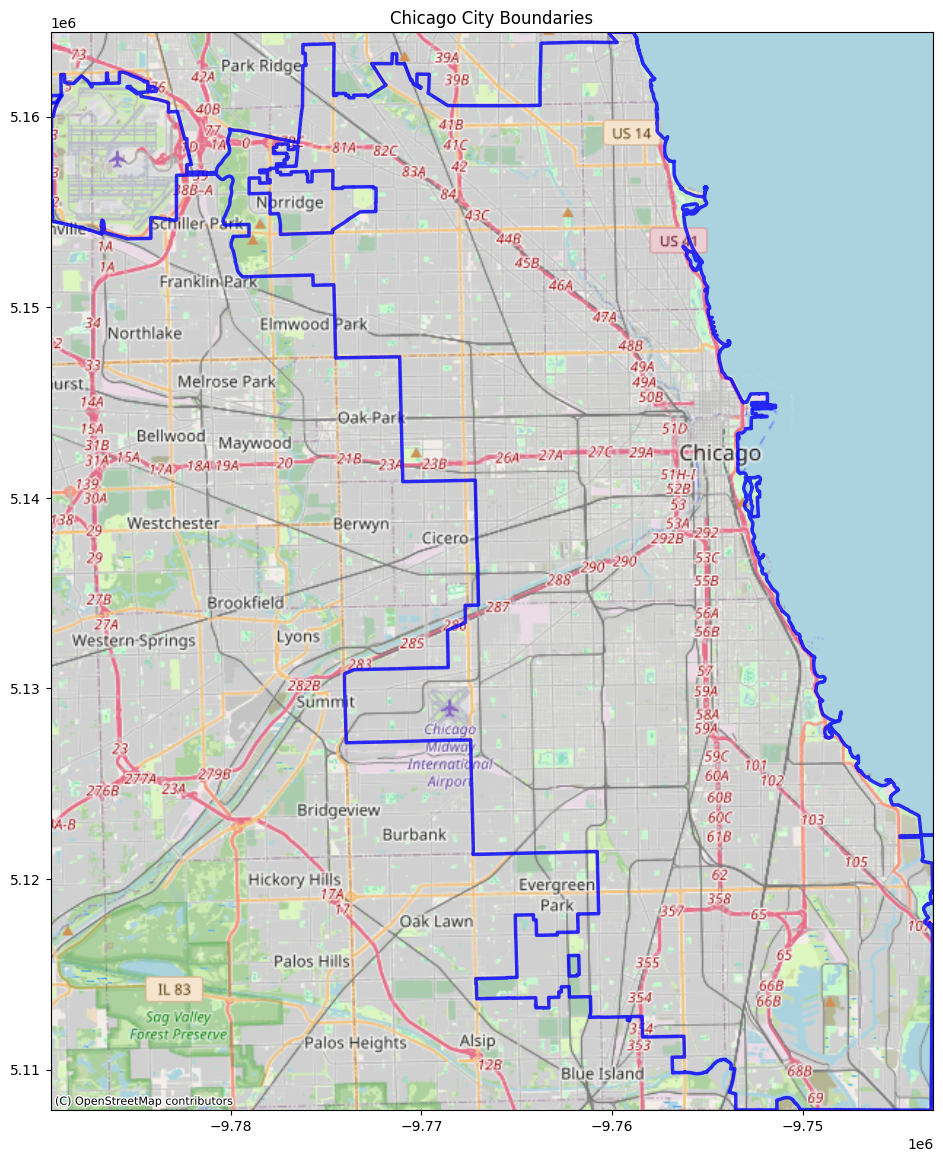

In [54]:
city = gpd.read_file(BOUNDARIES_DATA_PATH)
city_geo = city.geometry

fig, ax = plt.subplots(figsize=(14, 14))

# Convert to Web Mercator
city_bounds = gpd.GeoDataFrame(geometry=city_geo, crs='EPSG:4326').to_crs(epsg=3857)

# Plot first (so the extent exists)
city_bounds.plot(ax=ax, facecolor='none', edgecolor='blue', linewidth=2.5, alpha=0.8)

# Set extent for contextily
ax.set_xlim(city_bounds.total_bounds[0], city_bounds.total_bounds[2])
ax.set_ylim(city_bounds.total_bounds[1], city_bounds.total_bounds[3])

# Add basemap
ctx.add_basemap(ax, crs=city_bounds.crs, source=ctx.providers.OpenStreetMap.Mapnik)

ax.set_title('Chicago City Boundaries')
plt.show()


In [55]:
city_bounding_box_json_string = city_geo.to_json()
city_bounding_box_json = json.loads(city_bounding_box_json_string)
city_bounding_box_poly = city_bounding_box_json["features"][0]

# Computing hexagons for a given polygon
polygon_obj = city_bounding_box_poly["geometry"] # your geo json object
hexagons = h3.geo_to_cells(polygon_obj, res = H3_HEXAGON_RESOLUTION)

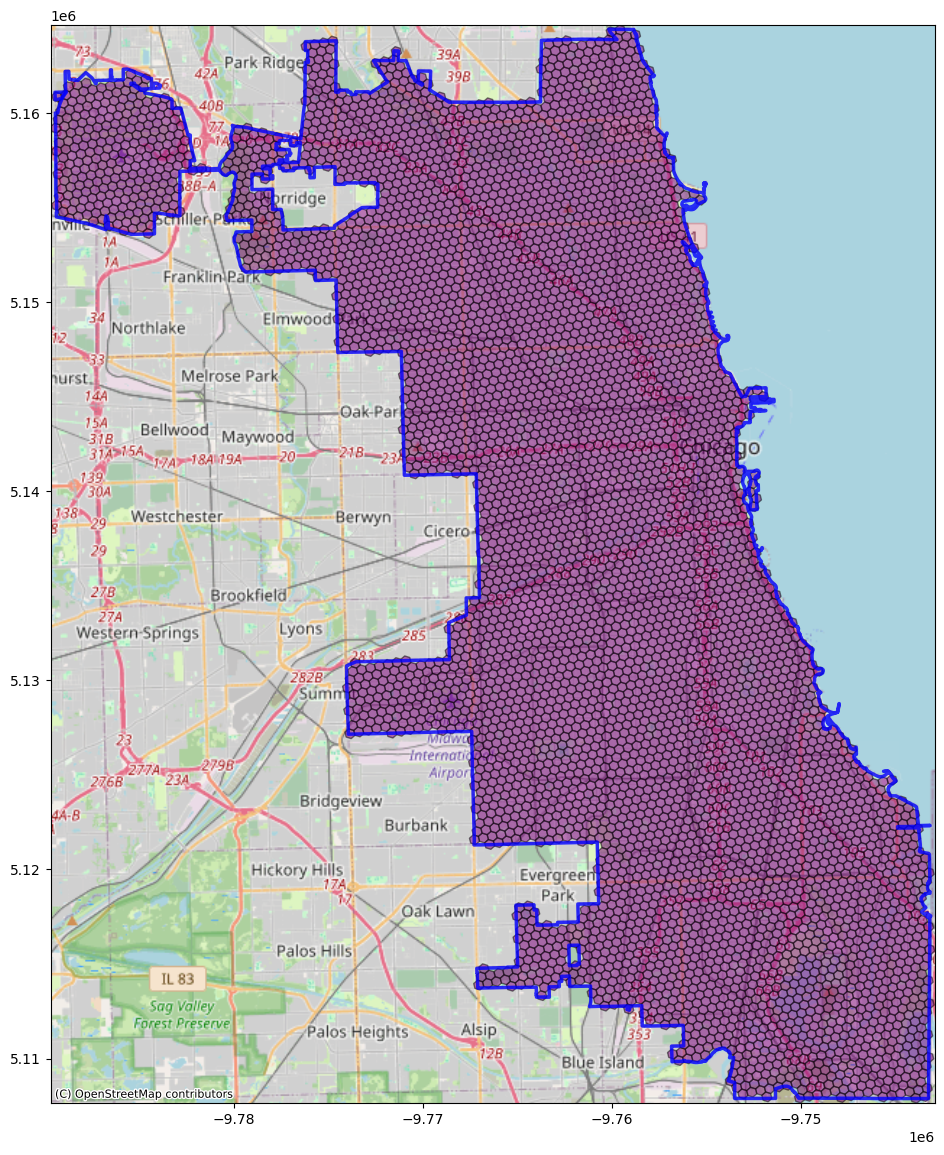

In [56]:
# Convert H3 hexes to geometry
# Create geometry series first
hex_geometries = [shape(h3.cells_to_geo([h])) for h in hexagons]

# Create GeoDataFrame with geometry from the start
df_boundaries = gpd.GeoDataFrame(
    {"h3_hex_id": list(hexagons)},
    geometry=hex_geometries,
    crs="EPSG:4326"
)

# Convert both to Web Mercator
df_web = df_boundaries.to_crs(3857)
city_bounds = city.to_crs(3857)

fig, ax = plt.subplots(figsize=(14, 14))

# Plot both in the same crs
df_web.plot(ax=ax, facecolor='purple', edgecolor='black', alpha=0.5)
city_bounds.plot(ax=ax, facecolor='none', edgecolor='blue', linewidth=2.5, alpha=0.8)

# Set extent from hexes
ax.set_xlim(df_web.total_bounds[0], df_web.total_bounds[2])
ax.set_ylim(df_web.total_bounds[1], df_web.total_bounds[3])

# Add basemap
ctx.add_basemap(ax, crs=df_web.crs, source=ctx.providers.OpenStreetMap.Mapnik)

plt.show()

### Taxi Trip data

In [57]:
taxi_data = pd.read_parquet(TAXI_DATA_PATH)
taxi_data.head()

,trip_id,taxi_id,trip_start_timestamp,trip_end_timestamp,trip_seconds,trip_miles,pickup_census_tract,dropoff_census_tract,pickup_community_area,dropoff_community_area,...,payment_type,company,pickup_centroid_latitude,pickup_centroid_longitude,dropoff_centroid_latitude,dropoff_centroid_longitude,pickup_ca_centroid_lat,pickup_ca_centroid_lon,dropoff_ca_centroid_lat,dropoff_ca_centroid_lon
0,0826d395e39c5ea146c37c8a78a03c012986b167,b89de8fefce2927a1bbc747ac861743fc5482ed36590d2...,2025-01-07 23:45:00,2025-01-08 00:00:00,1405.0,14.84,NaN,NaN,76,6,...,Credit Card,Taxicab Insurance Agency Llc,41.980264,-87.913625,41.944227,-87.655998,41.980264,-87.913625,41.944227,-87.655998
1,f7249eff1aad5ea1b3d53539a4003f3348786b27,60d596d3448473e61c35fc30a37bf8fda28d4ae7fa3bea...,2025-01-07 23:45:00,2025-01-08 00:00:00,318.0,1.30,NaN,NaN,8,8,...,Cash,Flash Cab,41.899602,-87.633308,41.899602,-87.633308,41.899602,-87.633308,41.899602,-87.633308
2,e7f005ad347a0f7f699523fc7843ba5f8b8792c1,0b0be23bf69b80dd81715f86c4e0887bbd5d9ebc2463b8...,2025-01-07 23:45:00,2025-01-07 23:45:00,419.0,0.87,NaN,NaN,8,8,...,Credit Card,Blue Ribbon Taxi Association,41.899602,-87.633308,41.899602,-87.633308,41.899602,-87.633308,41.899602,-87.633308
3,e6df7890fb2d74e09132af5cde612ea36ff5360d,488f74778b200fa256453e785aceb902249139d4880bc1...,2025-01-07 23:45:00,2025-01-08 00:00:00,1272.0,14.37,NaN,NaN,76,22,...,Credit Card,Chicago Taxicab,41.980264,-87.913625,41.922761,-87.699155,41.980264,-87.913625,41.922761,-87.699155
4,d5f005f6e423e808546dd1419fee4f2dafc55872,b9a58663518c48b09e83f462ca25ee0d702a2e4bc12199...,2025-01-07 23:45:00,2025-01-08 00:00:00,1368.0,17.25,NaN,NaN,76,28,...,Credit Card,City Service,41.980264,-87.913625,41.874005,-87.663518,41.980264,-87.913625,41.874005,-87.663518


In [58]:
taxi_data.count()

MemoryError: Unable to allocate 10.8 MiB for an array with shape (2, 5652351) and data type bool

In [ ]:
# Create GeoDataFrame for pickups and dropoffs
pickups_gdf = gpd.GeoDataFrame(
    taxi_data,
    geometry=gpd.points_from_xy(taxi_data['pickup_centroid_longitude'], taxi_data['pickup_centroid_latitude']),
    crs='EPSG:4326'
)

dropoffs_gdf = gpd.GeoDataFrame(
    taxi_data,
    geometry=gpd.points_from_xy(taxi_data['dropoff_centroid_longitude'], taxi_data['dropoff_centroid_latitude']),
    crs='EPSG:4326'
)

# Filter to city bounds
pickups_filtered = pickups_gdf.cx[city_geo.total_bounds[0]:city_geo.total_bounds[2], 
                                   city_geo.total_bounds[1]:city_geo.total_bounds[3]]
dropoffs_filtered = dropoffs_gdf.cx[city_geo.total_bounds[0]:city_geo.total_bounds[2], 
                                     city_geo.total_bounds[1]:city_geo.total_bounds[3]]

# Assign h3 cells
pickups_filtered['h3_hex_id'] = [h3.latlng_to_cell(lat, lon, H3_HEXAGON_RESOLUTION) 
                                  for lat, lon in zip(pickups_filtered.geometry.y, pickups_filtered.geometry.x)]
dropoffs_filtered['h3_hex_id'] = [h3.latlng_to_cell(lat, lon, H3_HEXAGON_RESOLUTION) 
                                   for lat, lon in zip(dropoffs_filtered.geometry.y, dropoffs_filtered.geometry.x)]

# Count per hexagon
pickups_counts = pickups_filtered.groupby('h3_hex_id').size().reset_index(name='count')
dropoffs_counts = dropoffs_filtered.groupby('h3_hex_id').size().reset_index(name='count')

# Merge with hexagon geometries
pickups_hex = df_boundaries.merge(pickups_counts, left_on='h3_hex_id', right_on='h3_hex_id', how='left')
pickups_hex['count'] = pickups_hex['count'].fillna(0)

dropoffs_hex = df_boundaries.merge(dropoffs_counts, left_on='h3_hex_id', right_on='h3_hex_id', how='left')
dropoffs_hex['count'] = dropoffs_hex['count'].fillna(0)

# Plot both
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

pickups_hex_with_crs = pickups_hex.set_crs('EPSG:4326')
dropoffs_hex_with_crs = dropoffs_hex.set_crs('EPSG:4326')

# Convert both to Web Mercator
pickups_hex = pickups_hex.to_crs(epsg=3857)
pickups_hex_web = pickups_hex_with_crs.to_crs(epsg=3857)
dropoffs_hex = dropoffs_hex.to_crs(epsg=3857)
dropoffs_hex_web = dropoffs_hex_with_crs.to_crs(epsg=3857)

# plot hexagons first
pickups_hex.plot(ax=axes[0], column='count', cmap='viridis', legend=True, 
                 edgecolor='black', linewidth=0.5, alpha=0.7)
axes[0].set_title('Taxi Pickups', fontsize=14)
axes[0].axis('off')

dropoffs_hex.plot(ax=axes[1], column='count', cmap='viridis', legend=True, 
                  edgecolor='black', linewidth=0.5, alpha=0.7)
axes[1].set_title('Taxi Dropoffs', fontsize=14)
axes[1].axis('off')

# Add basemap tiles on top of hexagons
ctx.add_basemap(axes[0], crs=pickups_hex_web.crs, source=ctx.providers.OpenStreetMap.Mapnik, zorder=0)
ctx.add_basemap(axes[1], crs=dropoffs_hex_web.crs, source=ctx.providers.OpenStreetMap.Mapnik, zorder=0)

plt.tight_layout()
plt.show()

print(f"Pickups: {len(pickups_filtered)}")
print(f"Dropoffs: {len(dropoffs_filtered)}")


MemoryError: Unable to allocate 733. MiB for an array with shape (17, 5652351) and data type float64

Looks like Dropoffs and Pickups are all centered around a similar location, seems weird, maybe check data or data cleaning.

## Census Tract Plotting

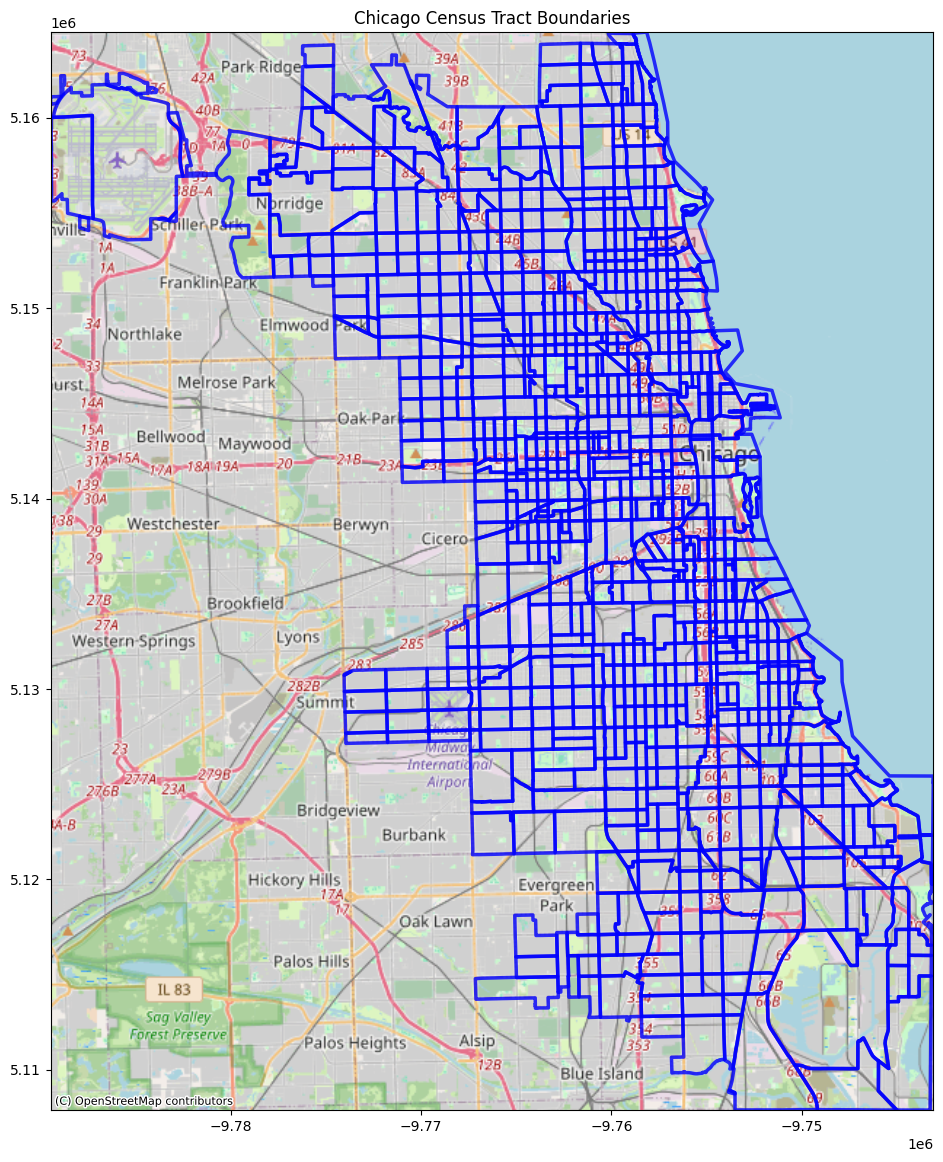

In [ ]:
census_tracts = gpd.read_file(CENSUS_TRACT_DATA_PATH)
census_tracts_geo = census_tracts.geometry

fig, ax = plt.subplots(figsize=(14, 14))

# Convert to Web Mercator
census_tracts_bounds = gpd.GeoDataFrame(geometry=census_tracts_geo, crs='EPSG:4326').to_crs(epsg=3857)

# Plot first (so the extent exists)
census_tracts_bounds.plot(ax=ax, facecolor='none', edgecolor='blue', linewidth=2.5, alpha=0.8)

# Set extent for contextily
ax.set_xlim(census_tracts_bounds.total_bounds[0], census_tracts_bounds.total_bounds[2])
ax.set_ylim(census_tracts_bounds.total_bounds[1], census_tracts_bounds.total_bounds[3])

# Add basemap
ctx.add_basemap(ax, crs=census_tracts_bounds.crs, source=ctx.providers.OpenStreetMap.Mapnik)

ax.set_title('Chicago Census Tract Boundaries')
plt.show()


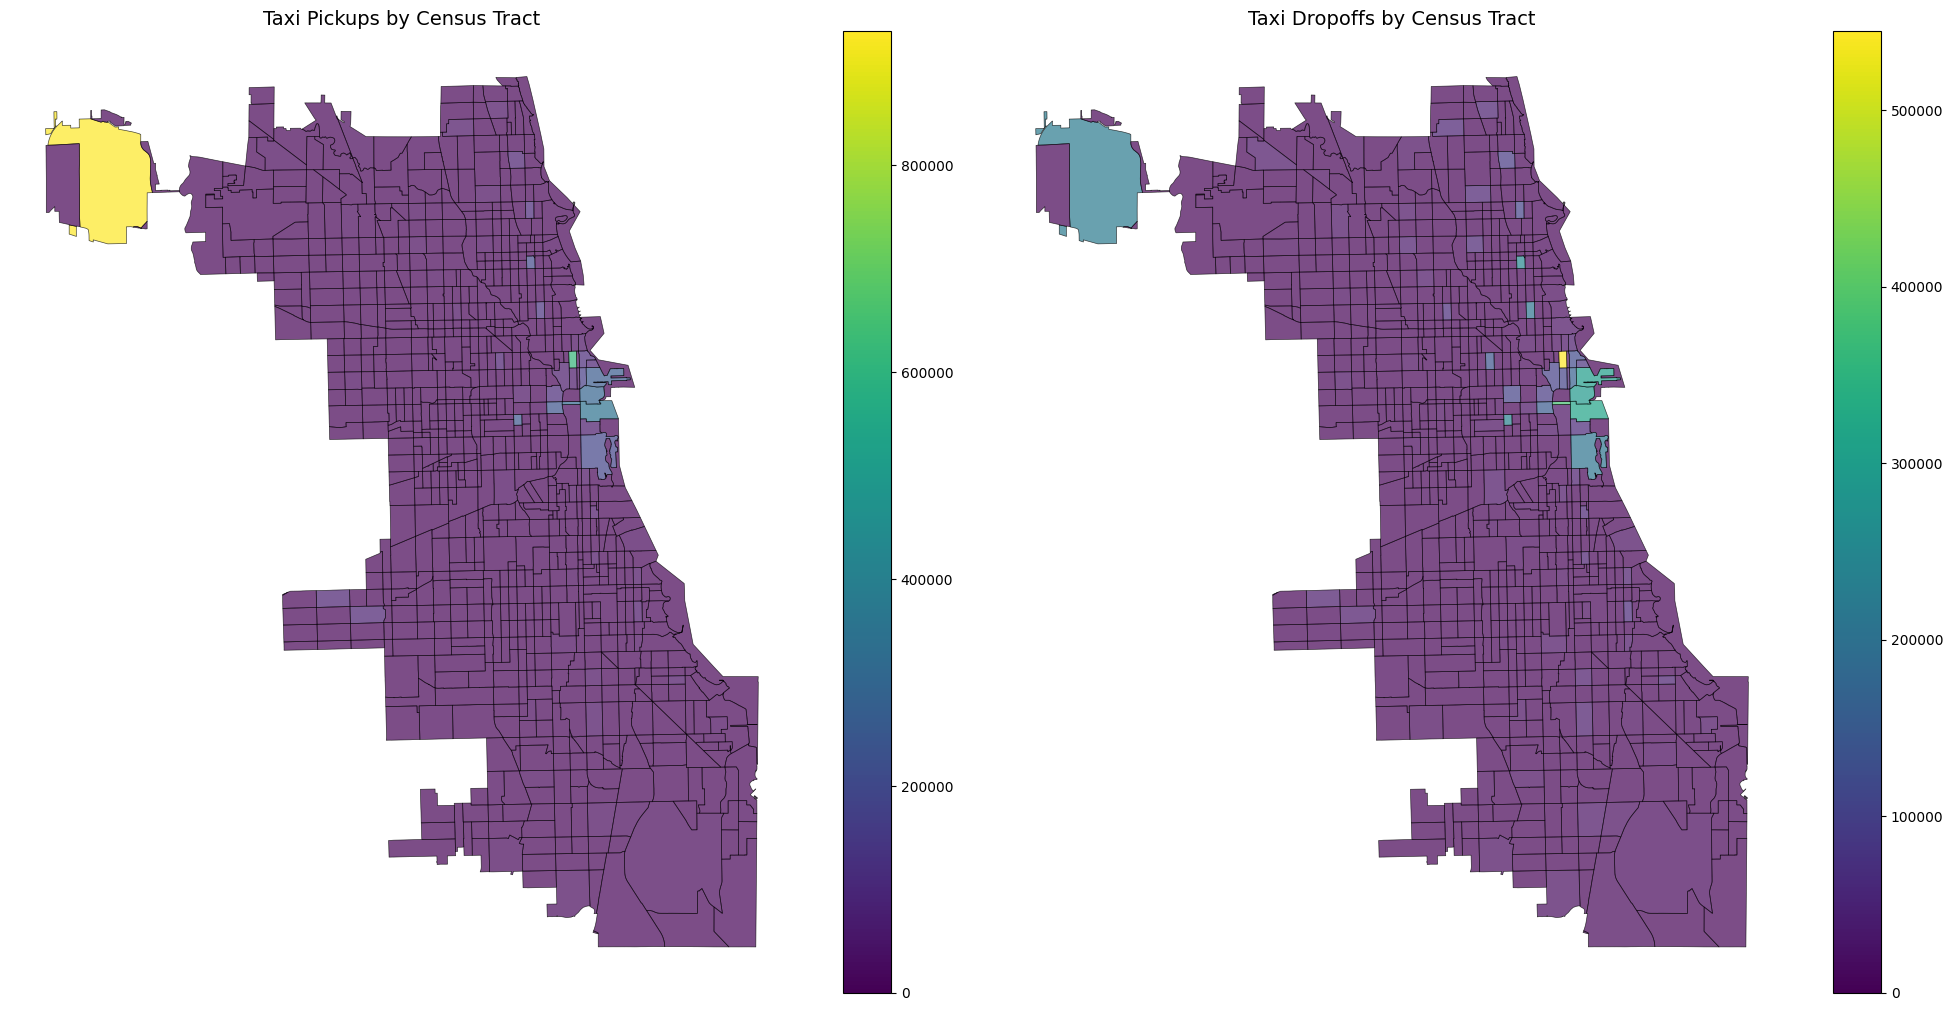

Pickups by tract - min: 0.0, max: 930101.0, mean: 6437.76
Dropoffs by tract - min: 0.0, max: 544885.0, mean: 6437.76


In [ ]:
## Pickups and Dropoffs by Census Tract

# Count pickups and dropoffs per census tract using spatial join
pickups_by_tract = gpd.sjoin(pickups_filtered, census_tracts, how='left', predicate='within')
dropoffs_by_tract = gpd.sjoin(dropoffs_filtered, census_tracts, how='left', predicate='within')

# Count records per tract (using the index from census_tracts)
pickups_counts_tract = pickups_by_tract.groupby('index_right').size().reset_index(name='count')
dropoffs_counts_tract = dropoffs_by_tract.groupby('index_right').size().reset_index(name='count')

# Merge counts with census tract geometries
pickups_tracts = census_tracts.reset_index().merge(pickups_counts_tract, left_on='index', right_on='index_right', how='left')
dropoffs_tracts = census_tracts.reset_index().merge(dropoffs_counts_tract, left_on='index', right_on='index_right', how='left')

pickups_tracts['count'] = pickups_tracts['count'].fillna(0)
dropoffs_tracts['count'] = dropoffs_tracts['count'].fillna(0)

# Plot both
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

pickups_tracts.plot(ax=axes[0], column='count', cmap='viridis', legend=True, 
                    edgecolor='black', linewidth=0.5, alpha=0.7)
axes[0].set_title('Taxi Pickups by Census Tract', fontsize=14)
axes[0].axis('off')

dropoffs_tracts.plot(ax=axes[1], column='count', cmap='viridis', legend=True, 
                     edgecolor='black', linewidth=0.5, alpha=0.7)
axes[1].set_title('Taxi Dropoffs by Census Tract', fontsize=14)
axes[1].axis('off')

plt.tight_layout()
plt.show()

print(f"Pickups by tract - min: {pickups_tracts['count'].min()}, max: {pickups_tracts['count'].max()}, mean: {pickups_tracts['count'].mean():.2f}")
print(f"Dropoffs by tract - min: {dropoffs_tracts['count'].min()}, max: {dropoffs_tracts['count'].max()}, mean: {dropoffs_tracts['count'].mean():.2f}")


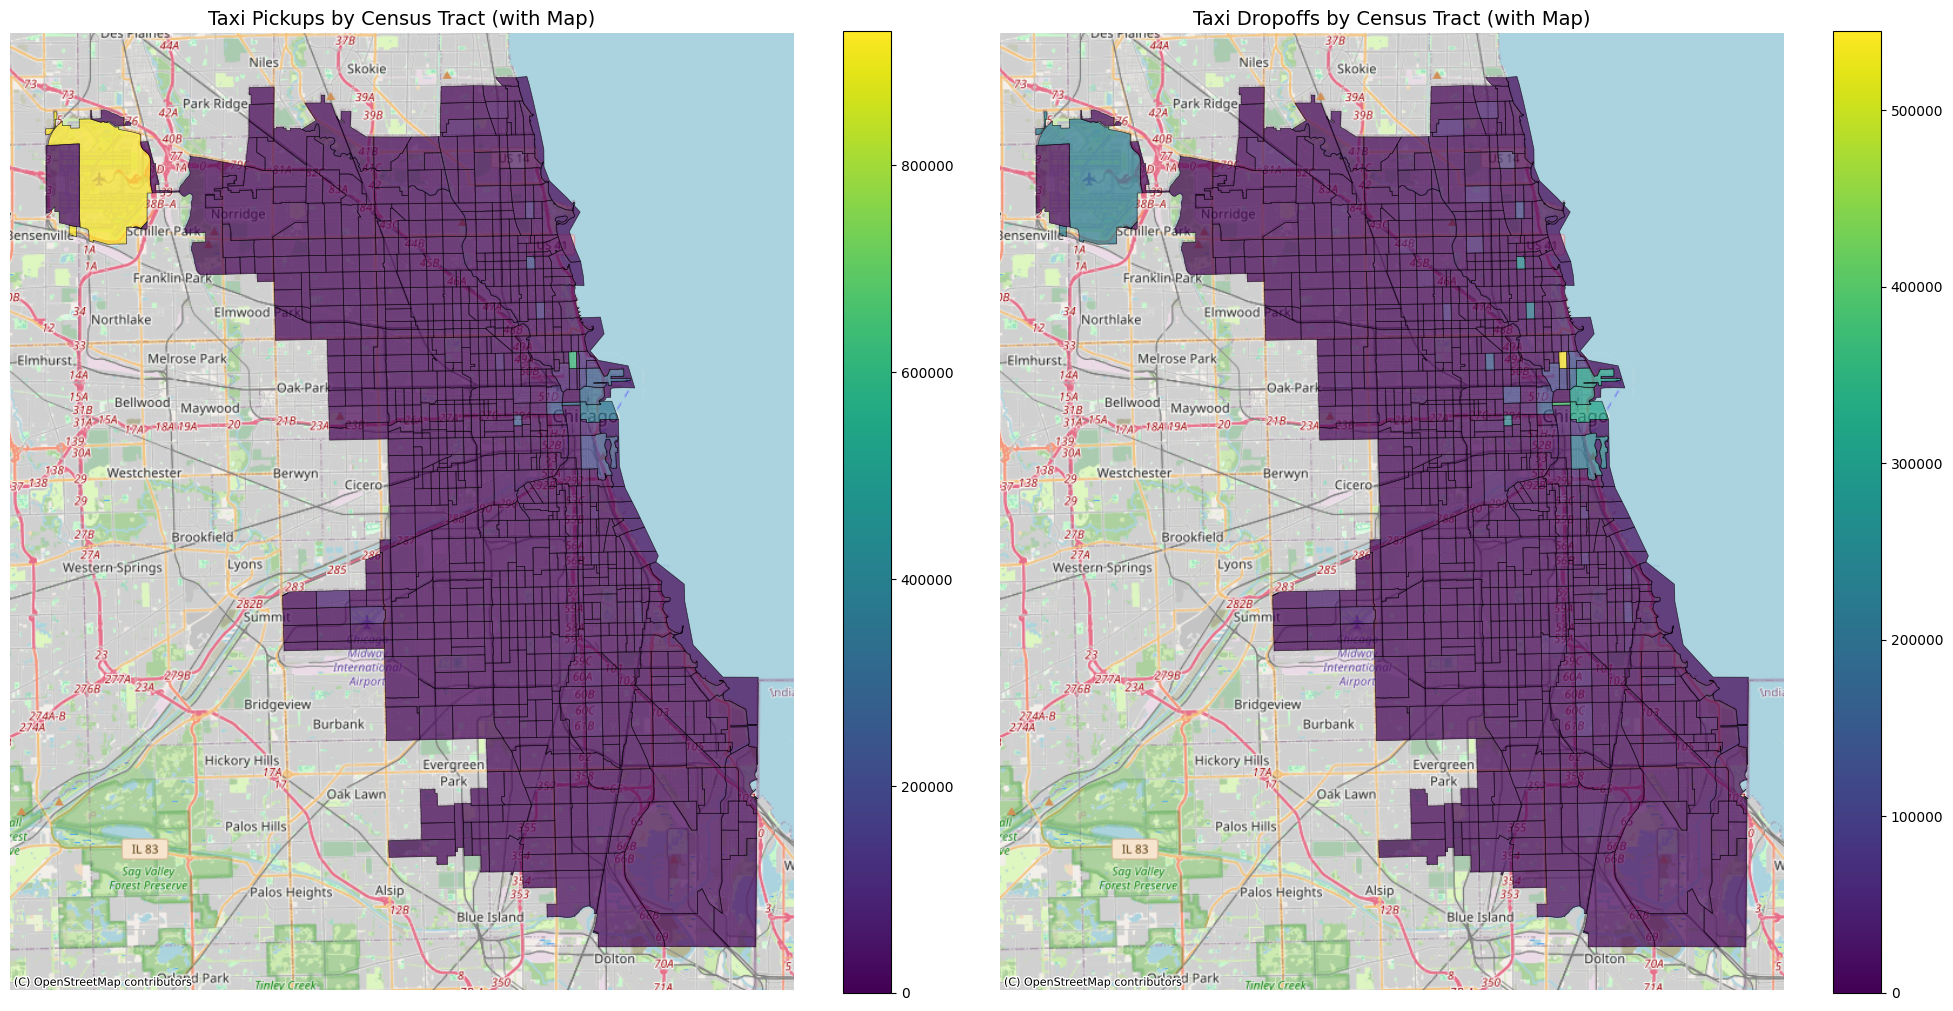

In [ ]:
## Census Tract Heatmaps with Basemap

# Convert to Web Mercator for mapping
pickups_tracts_web = pickups_tracts.to_crs(epsg=3857)
dropoffs_tracts_web = dropoffs_tracts.to_crs(epsg=3857)

fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# Plot pickups
pickups_tracts_web.plot(ax=axes[0], column='count', cmap='viridis', legend=True, 
                        edgecolor='black', linewidth=0.5, alpha=0.7, zorder=1)
ctx.add_basemap(axes[0], crs=pickups_tracts_web.crs, source=ctx.providers.OpenStreetMap.Mapnik, zorder=0)
axes[0].set_title('Taxi Pickups by Census Tract (with Map)', fontsize=14)
axes[0].axis('off')

# Plot dropoffs
dropoffs_tracts_web.plot(ax=axes[1], column='count', cmap='viridis', legend=True, 
                         edgecolor='black', linewidth=0.5, alpha=0.7, zorder=1)
ctx.add_basemap(axes[1], crs=dropoffs_tracts_web.crs, source=ctx.providers.OpenStreetMap.Mapnik, zorder=0)
axes[1].set_title('Taxi Dropoffs by Census Tract (with Map)', fontsize=14)
axes[1].axis('off')

plt.tight_layout()
plt.show()
